# Lab 10 · Auditoría de sesgos y riesgos del modelo telco

Notebook para auditar un modelo de churn: accuracy global, métricas por grupo, falsos positivos/negativos, paridad demográfica, igualdad de oportunidades, variables proxy y gobernanza.

In [1]:
# Instalación de dependencias básicas. En SageMaker normalmente ya están instaladas.
%pip -q install pandas numpy matplotlib networkx scikit-learn s3fs

import os
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Por defecto se leen los CSV incluidos en la carpeta local data/.
# Si prefieres leer desde S3, cambia USE_S3=True y ajusta S3_PREFIX.
USE_S3 = False
DATA_DIR = Path('data')
S3_PREFIX = 's3://TU_BUCKET/TU_CARPETA'  # ejemplo: s3://mi-bucket/graph

def data_path(filename):
    return f"{S3_PREFIX}/{filename}" if USE_S3 else str(DATA_DIR / filename)

OUTPUT_DIR = Path('outputs')
OUTPUT_DIR.mkdir(exist_ok=True)

from sklearn.metrics import confusion_matrix

Note: you may need to restart the kernel to use updated packages.


## Parte A. Cargar datos de auditoría

In [2]:
df = pd.read_csv(data_path('telco_model_audit_lab10.csv'))
print(df.shape)
display(df.head())

(1000, 8)


,customer_id,region,zone_type,tenure_months,monthly_price,y_true,y_pred,y_score
0,CUST-00001,Madrid,urbana,33,57.94,0,0,0.327
1,CUST-00002,Madrid,urbana,68,38.99,0,0,0.070
2,CUST-00003,Zaragoza,rural,45,39.56,0,0,0.000
3,CUST-00004,Valencia,periurbana,77,41.27,1,0,0.093
4,CUST-00005,Bilbao,rural,31,55.88,0,0,0.341


## Parte B. Rendimiento global y desagregado

In [3]:
accuracy_global = (df['y_true'] == df['y_pred']).mean()
print(f'Accuracy global: {accuracy_global:.3f}')

acc_region = df.groupby('region').apply(lambda g: (g['y_true'] == g['y_pred']).mean()).rename('accuracy').sort_values()
acc_zone = df.groupby('zone_type').apply(lambda g: (g['y_true'] == g['y_pred']).mean()).rename('accuracy').sort_values()
display(acc_region.round(3).reset_index())
display(acc_zone.round(3).reset_index())
acc_region.to_csv(OUTPUT_DIR/'lab10_accuracy_region.csv')
acc_zone.to_csv(OUTPUT_DIR/'lab10_accuracy_zone_type.csv')

Accuracy global: 0.644


/tmp/ipykernel_19050/3325851794.py:4: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  acc_region = df.groupby('region').apply(lambda g: (g['y_true'] == g['y_pred']).mean()).rename('accuracy').sort_values()
/tmp/ipykernel_19050/3325851794.py:5: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  acc_zone = df.groupby('zone_type').apply(lambda g: (g['y_true'] == g['y_pred']).mean()).rename('accuracy').sort_values()


,region,accuracy
0,Zaragoza,0.580
1,Bilbao,0.609
2,Sevilla,0.626
3,Valencia,0.654
4,Barcelona,0.665
5,Madrid,0.706


,zone_type,accuracy
0,rural,0.593
1,periurbana,0.642
2,urbana,0.686


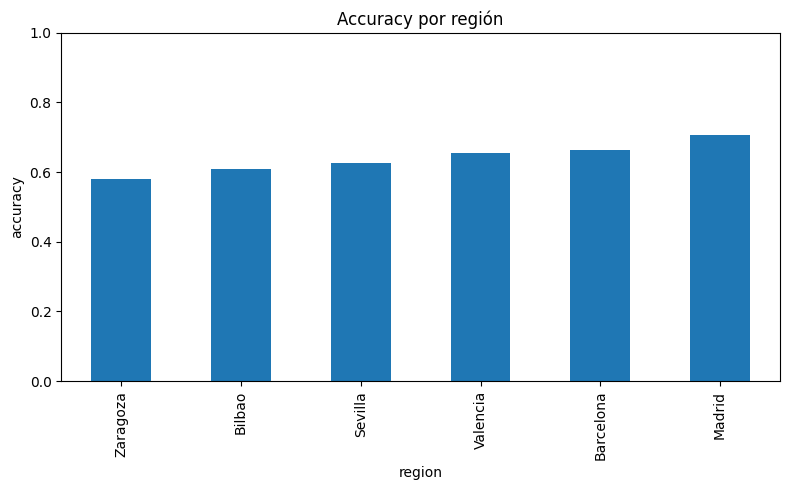

In [4]:
plt.figure(figsize=(8,5))
acc_region.sort_values().plot(kind='bar')
plt.ylim(0,1)
plt.ylabel('accuracy')
plt.title('Accuracy por región')
plt.tight_layout()
plt.savefig(OUTPUT_DIR/'lab10_accuracy_por_region.png', dpi=150, bbox_inches='tight')
plt.show()

## Parte C. Disparidad en errores

In [5]:
def metricas_grupo(g):
    tp = int(((g.y_true==1) & (g.y_pred==1)).sum())
    tn = int(((g.y_true==0) & (g.y_pred==0)).sum())
    fp = int(((g.y_true==0) & (g.y_pred==1)).sum())
    fn = int(((g.y_true==1) & (g.y_pred==0)).sum())
    precision = tp/(tp+fp) if (tp+fp)>0 else np.nan
    recall = tp/(tp+fn) if (tp+fn)>0 else np.nan
    fpr = fp/(fp+tn) if (fp+tn)>0 else np.nan
    return pd.Series({'clientes':len(g), 'TP':tp, 'TN':tn, 'FP':fp, 'FN':fn, 'precision':precision, 'recall':recall, 'FPR':fpr})

met_region = df.groupby('region').apply(metricas_grupo).sort_values('recall')
display(met_region.round(3))
met_region.to_csv(OUTPUT_DIR/'lab10_metricas_error_region.csv')

/tmp/ipykernel_19050/745069926.py:11: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  met_region = df.groupby('region').apply(metricas_grupo).sort_values('recall')


,clientes,TP,TN,FP,FN,precision,recall,FPR
region,,,,,,,,
Barcelona,188.0,7.0,118.0,18.0,45.0,0.280,0.135,0.132
Zaragoza,169.0,12.0,86.0,19.0,52.0,0.387,0.188,0.181
Madrid,194.0,10.0,127.0,14.0,43.0,0.417,0.189,0.099
Sevilla,139.0,12.0,75.0,12.0,40.0,0.500,0.231,0.138
Bilbao,128.0,11.0,67.0,19.0,31.0,0.367,0.262,0.221
Valencia,182.0,19.0,100.0,29.0,34.0,0.396,0.358,0.225


## Parte D. Métricas formales de equidad

In [6]:
# Paridad demográfica: tasa de predicciones positivas por grupo.
paridad = df.groupby('region')['y_pred'].mean().rename('tasa_positivos').sort_values(ascending=False)
# Igualdad de oportunidades: recall por grupo.
recall = met_region['recall']
print('Paridad demográfica por región:')
display(paridad.round(3).reset_index())
print('Brecha de tasa de positivos:', round(paridad.max() - paridad.min(), 3))
print('Recall por región:')
display(recall.round(3).reset_index())
print('Brecha de recall:', round(recall.max() - recall.min(), 3))

pd.concat([paridad, recall.rename('recall')], axis=1).to_csv(OUTPUT_DIR/'lab10_metricas_equidad_region.csv')

Paridad demográfica por región:


,region,tasa_positivos
0,Valencia,0.264
1,Bilbao,0.234
2,Zaragoza,0.183
3,Sevilla,0.173
4,Barcelona,0.133
5,Madrid,0.124


Brecha de tasa de positivos: 0.14
Recall por región:


,region,recall
0,Barcelona,0.135
1,Zaragoza,0.188
2,Madrid,0.189
3,Sevilla,0.231
4,Bilbao,0.262
5,Valencia,0.358


Brecha de recall: 0.224


## Parte E. Variables proxy y bucle de retroalimentación

In [7]:
proxy_zone = df.groupby('zone_type').agg(
    clientes=('customer_id','count'),
    churn_real=('y_true','mean'),
    churn_predicho=('y_pred','mean'),
    precio_medio=('monthly_price','mean'),
    tenure_medio=('tenure_months','mean')
).round(3).sort_values('churn_predicho', ascending=False)
display(proxy_zone)
proxy_zone.to_csv(OUTPUT_DIR/'lab10_proxy_zone_type.csv')

print('Reflexión: si zone_type o region resumen desigualdad territorial, pueden actuar como proxy. No siempre deben eliminarse, pero sí documentarse y auditarse.')

,clientes,churn_real,churn_predicho,precio_medio,tenure_medio
zone_type,,,,,
periurbana,321,0.327,0.224,48.150,33.804
rural,297,0.357,0.205,44.154,34.643
urbana,382,0.275,0.128,53.989,35.296


Reflexión: si zone_type o region resumen desigualdad territorial, pueden actuar como proxy. No siempre deben eliminarse, pero sí documentarse y auditarse.


## Parte F. Veredicto y mitigación

Completa esta celda con un veredicto razonado. La estructura siguiente te sirve para el entregable.

In [8]:
mitigacion = pd.DataFrame([
    {'medida':'Recalibrar umbrales por grupo', 'objetivo':'reducir brecha de recall sin disparar falsos positivos'},
    {'medida':'Reentrenar con datos más equilibrados', 'objetivo':'mejorar rendimiento en regiones con peor accuracy'},
    {'medida':'Monitorización continua', 'objetivo':'detectar deriva de rendimiento y equidad'},
    {'medida':'Model card y revisión humana', 'objetivo':'documentar limitaciones y evitar decisiones automáticas dañinas'},
])
display(mitigacion)
mitigacion.to_csv(OUTPUT_DIR/'lab10_mitigacion_gobernanza.csv', index=False)

,medida,objetivo
0,Recalibrar umbrales por grupo,reducir brecha de recall sin disparar falsos p...
1,Reentrenar con datos más equilibrados,mejorar rendimiento en regiones con peor accuracy
2,Monitorización continua,detectar deriva de rendimiento y equidad
3,Model card y revisión humana,documentar limitaciones y evitar decisiones au...


## Cierre

Un modelo con buena accuracy global puede ser inaceptable si falla sistemáticamente para determinados grupos. El entregable debe terminar con un veredicto: desplegar, desplegar con condiciones o no desplegar.